## ARIMA with LSTM 

we utilize the Wind Turbine SCADA dataset to forecast LV ActivePower (kW). Wind energy generation is highly dynamic—driven by strong underlying seasonal trends mixed with complex, unpredictable weather fluctuations. This makes it an ideal candidate for a hybrid forecasting approach, much like handling volatile industrial sensor data where both steady states and sudden anomalies exist.

###  Data Loading & Preprocessing
Loads the Wind Turbine SCADA dataset, converts the timestamp column into a proper datetime object, sets it as the index, and ensures chronological sorting. This strict time-based ordering is crucial for accurate sequence modeling.

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load the time series data
data = pd.read_csv('T1.csv')
data['Date/Time'] = pd.to_datetime(data['Date/Time'], format='mixed')
data.set_index('Date/Time', inplace=True)

# Sort index chronologically
data.sort_index(inplace=True)

time_series = data['LV ActivePower (kW)'] 

In [4]:
time_series

Date/Time
2018-01-01 00:00:00     380.047791
2018-01-01 00:10:00     453.769196
2018-01-01 00:20:00     306.376587
2018-01-01 00:30:00     419.645905
2018-01-01 00:40:00     380.650696
                          ...     
2018-12-31 23:10:00    2963.980957
2018-12-31 23:20:00    1684.353027
2018-12-31 23:30:00    2201.106934
2018-12-31 23:40:00    2515.694092
2018-12-31 23:50:00    2820.466064
Name: LV ActivePower (kW), Length: 50530, dtype: float64

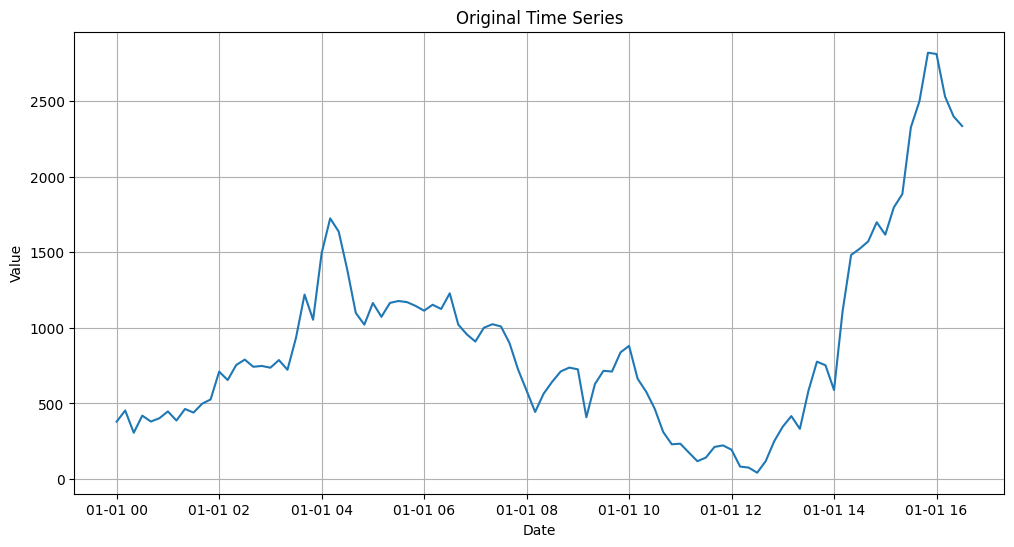

In [5]:
# Plot the original data
plt.figure(figsize=(12, 6))
plt.plot(time_series[:100])
plt.title('Original Time Series')
plt.xlabel('Date')
plt.ylabel('Value')
plt.grid()
plt.show()

###  Stationarity Check
Performs the Augmented Dickey-Fuller (ADF) test to evaluate if the time series is stationary. A p-value of less than 0.05 indicates stationarity, which is a key requirement for determining the differencing parameter (d) in ARIMA.

In [6]:
from statsmodels.tsa.stattools import adfuller
# Perform the ADF test
result = adfuller(time_series)
print('ADF Statistic:', result[0])
print('p-value:', result[1])
# Interpretation
if float(result[1]) <= 0.05:
 print("The time series is stationary.")
else:
 print("The time series is non-stationary.")

ADF Statistic: -16.341420834887312
p-value: 2.9932700224329417e-29
The time series is stationary.


###  Autocorrelation Analysis
Generates Autocorrelation (ACF) and Partial Autocorrelation (PACF) plots. These visualizations help in identifying the optimal AutoRegressive (p) and Moving Average (q) parameters for the base ARIMA model.

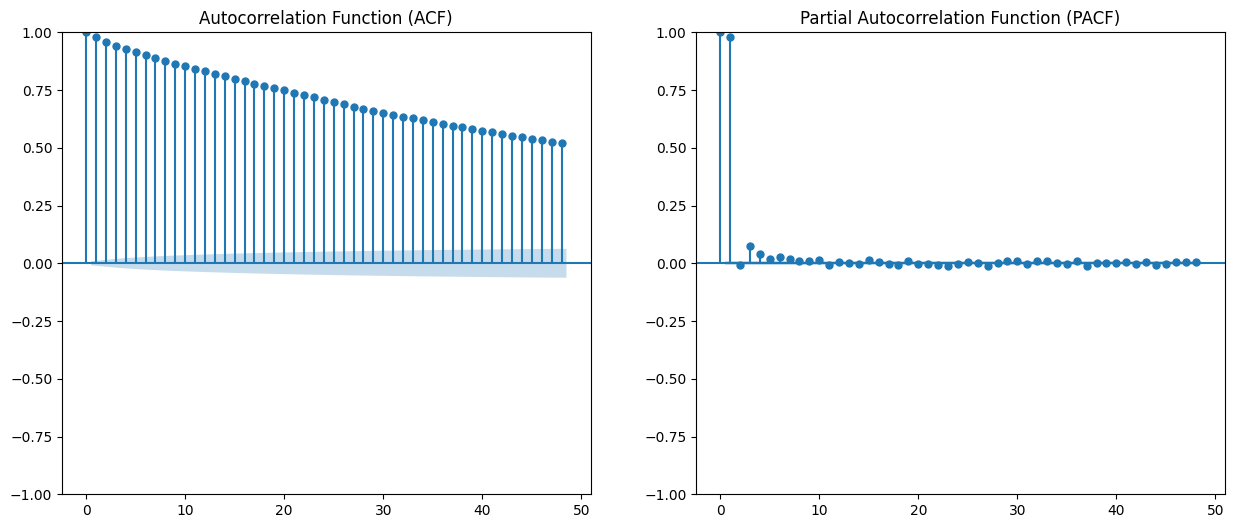

In [7]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
# ACF and PACF plots
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
plot_acf(time_series, ax=ax[0])
ax[0].set_title('Autocorrelation Function (ACF)')
plot_pacf(time_series, ax=ax[1])
ax[1].set_title('Partial Autocorrelation Function (PACF)')
plt.show()

###  Base ARIMA Model Implementation
Initializes and fits the ARIMA model to capture the baseline linear trends and predictable seasonality within the active power generation data. It then extracts fitted predictions for the testing period.

In [10]:
from statsmodels.tsa.arima.model import ARIMA
# Define the ARIMA model with chosen parameters (example: p=1, d=1, q=1)
model = ARIMA(time_series, order=(2, 0, 0))
# Fit the model
model_fit = model.fit()
# Print the summary of the model
print(model_fit.summary())

                                SARIMAX Results                                
Dep. Variable:     LV ActivePower (kW)   No. Observations:                50530
Model:                  ARIMA(2, 0, 0)   Log Likelihood             -353397.975
Date:                 Wed, 10 Jun 2026   AIC                         706803.950
Time:                         13:40:48   BIC                         706839.272
Sample:                              0   HQIC                        706815.009
                               - 50530                                         
Covariance Type:                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1307.6843     69.554     18.801      0.000    1171.362    1444.007
ar.L1          0.9867      0.002    412.669      0.000       0.982       0.991
ar.L2         -0.0072      0.002     -3.531 

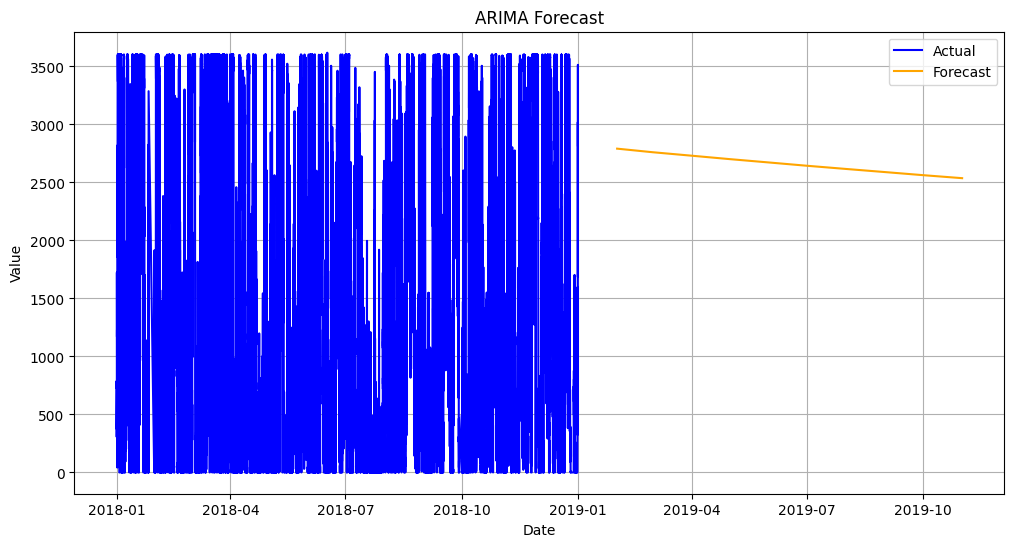

In [11]:
# Forecasting future values
forecast_steps = 10 # Specify the number of steps to forecast
forecast = model_fit.forecast(steps=forecast_steps)
# Plot the forecast
plt.figure(figsize=(12, 6))
plt.plot(time_series, label='Actual', color='blue')
plt.plot(pd.date_range(time_series.index[-1], periods=forecast_steps + 1, freq='ME')[1:], forecast, label='Forecast', color='orange')
plt.title('ARIMA Forecast')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid()
plt.show()

###  Isolating the Residuals (Noise)
Extracts the residuals (errors) from the fitted ARIMA model. These residuals represent the complex, non-linear volatility and sudden weather-driven fluctuations that the linear ARIMA model failed to capture.

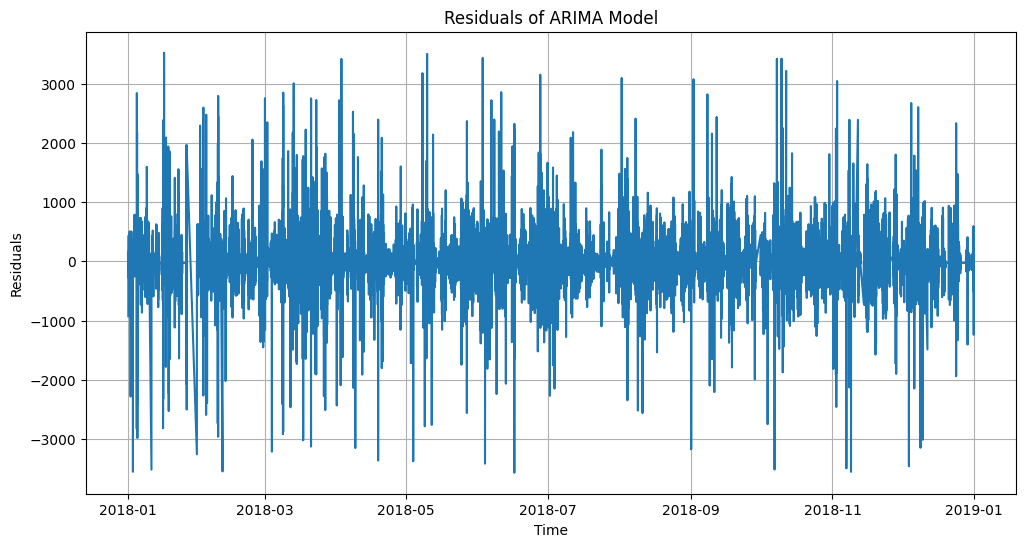

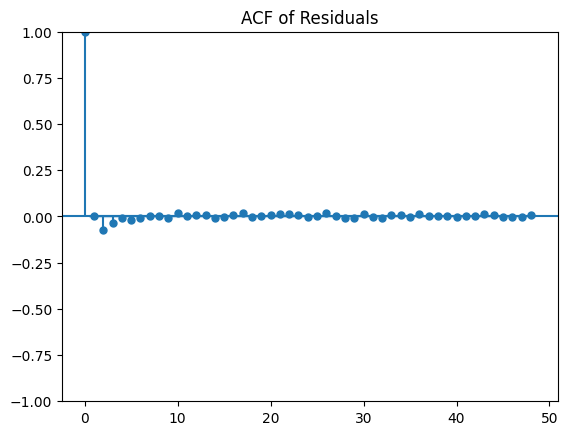

ADF Statistic: -30.56615239083536
p-value: 0.0


In [12]:
# Plot residuals
residuals = model_fit.resid
plt.figure(figsize=(12, 6))
plt.plot(residuals)
plt.title('Residuals of ARIMA Model')
plt.xlabel('Time')
plt.ylabel('Residuals')
plt.grid()
plt.show()
# ACF of residuals
plot_acf(residuals)
plt.title('ACF of Residuals')
plt.show()
# Perform the ADF test on residuals
result_residuals = adfuller(residuals)
print('ADF Statistic:', result_residuals[0])
print('p-value:', result_residuals[1])

###  LSTM Data Preparation
Scales the extracted residuals to a `[0, 1]` range using `MinMaxScaler` to prevent exploding gradients during neural network training. The data is then transformed into overlapping sequential windows to provide chronological context to the LSTM.

In [13]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Scale the residuals to a range of [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))
residuals_scaled = scaler.fit_transform(residuals.values.reshape(-1, 1))

In [14]:
# Split data into training and test sets
train_size = int(len(residuals_scaled) * 0.8)
train, test = residuals_scaled[:train_size], residuals_scaled[train_size:]

In [15]:
train

array([[0.372599  ],
       [0.51106087],
       [0.48001699],
       ...,
       [0.49955175],
       [0.49955175],
       [0.49955175]], shape=(40424, 1))

In [16]:
# Create sequences for LSTM
def create_sequences(data, seq_length):
    sequences = []
    labels = []
    for i in range(seq_length, len(data)):
        sequences.append(data[i-seq_length:i, 0])
        labels.append(data[i, 0])
    return np.array(sequences), np.array(labels)

In [17]:
# seq_length = 10 # Define the sequence length
seq_length = 72
X_train, y_train = create_sequences(train, seq_length)
X_test, y_test = create_sequences(test, seq_length)

In [18]:
# Reshape data to fit LSTM model (samples, time steps, features)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

###  Training the LSTM Network
Builds and compiles a Long Short-Term Memory (LSTM) neural network. The network is trained on the historical sequences of residuals to learn and predict the underlying non-linear patterns.

Epoch 1/30
631/631 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - loss: 0.0031 - val_loss: 0.0013
Epoch 2/30
631/631 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - loss: 0.0015 - val_loss: 0.0015
Epoch 3/30
631/631 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - loss: 0.0015 - val_loss: 0.0013
Epoch 4/30
631/631 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - loss: 0.0015 - val_loss: 0.0014
Epoch 5/30
631/631 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - loss: 0.0015 - val_loss: 0.0014
Epoch 6/30
631/631 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - loss: 0.0015 - val_loss: 0.0013
Epoch 7/30
631/631 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - loss: 0.0015 - val_loss: 0.0013
Epoch 8/30
631/631 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - loss: 0.0014 - val_loss: 0.0013
Epoch 9/30
631/631 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - loss: 0.0014 - val_loss: 0.0013
Epoch 10/30
631/631 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - loss: 0.0014 - val_loss: 0.0013
Epoch 11/30
631/631 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - loss: 0.0014 - val_loss: 0.0013
Epoch 12/30
631/631 ━━━━━━━━━━

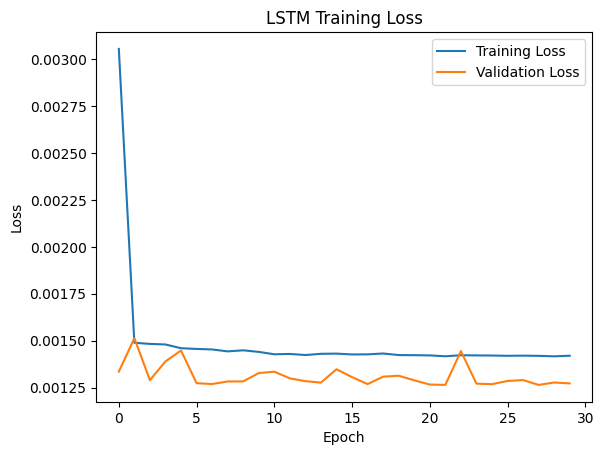

In [19]:
from keras.models import Sequential
from keras.layers import LSTM, Dense

# Define the LSTM model
model = Sequential()

model.add(LSTM(50, return_sequences=False, input_shape=(X_train.shape[1], 1)))
model.add(Dense(1)) # Output layer for regression (single value)

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error',)

# Training the model
history = model.fit(X_train, y_train, epochs=30, batch_size=64, validation_data=(X_test,y_test), verbose='auto')

# plot the training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

###  Generating Non-Linear Predictions
Generates predictions on the unseen test residuals using the trained LSTM model. An inverse transformation is then applied to scale the neural network outputs back to their original metric (kW).

314/314 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


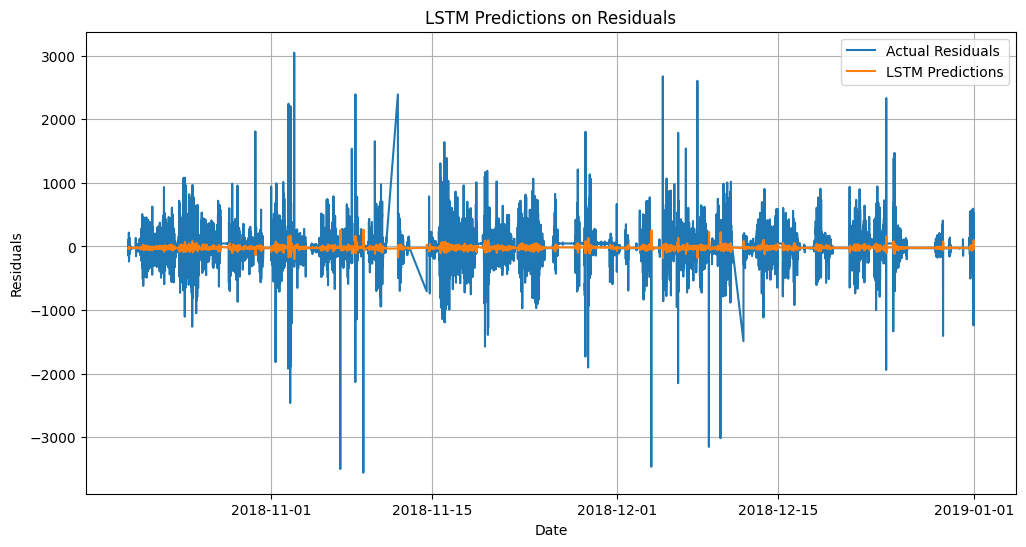

In [20]:
# Make predictions on the test set
lstm_predictions = model.predict(X_test)
# Invert scaling to get the original residual values
lstm_predictions_rescaled = scaler.inverse_transform(lstm_predictions)
# Plot the LSTM predictions vs actual residuals
plt.figure(figsize=(12, 6))
plt.plot(residuals.index[train_size + seq_length:], residuals.values[train_size + seq_length:], label='Actual Residuals')
plt.plot(residuals.index[train_size + seq_length:], lstm_predictions_rescaled, label='LSTM Predictions')
plt.title('LSTM Predictions on Residuals')
plt.xlabel('Date')
plt.ylabel('Residuals')
plt.legend()
plt.grid()
plt.show()

In [21]:
# ARIMA predictions (for the same test period as the LSTM)
# arima_predictions = model_fit.forecast(steps=len(test))
    
arima_predictions = model_fit.predict(start=train_size, end=len(time_series)-1)

# Ensure arima_predictions is a numpy array/pandas series for easy math
arima_predictions = arima_predictions.values

### The Hybrid Forecast
Aligns the ARIMA and LSTM output arrays to resolve sequence length differences. The final hybrid forecast is generated by adding the linear ARIMA predictions to the non-linear LSTM corrections, resulting in a highly robust model compared against actual actual values.

In [22]:
# Define the window size (calculate the difference)
window_size = len(arima_predictions) - len(lstm_predictions_rescaled.flatten()) # Ye 10 aayega

# Slice the ARIMA predictions to match shape of the lstm
arima_predictions_aligned = arima_predictions[window_size:]

# Add ARIMA + LSTM output (now the shape is 10096)
final_predictions = arima_predictions_aligned + lstm_predictions_rescaled.flatten()

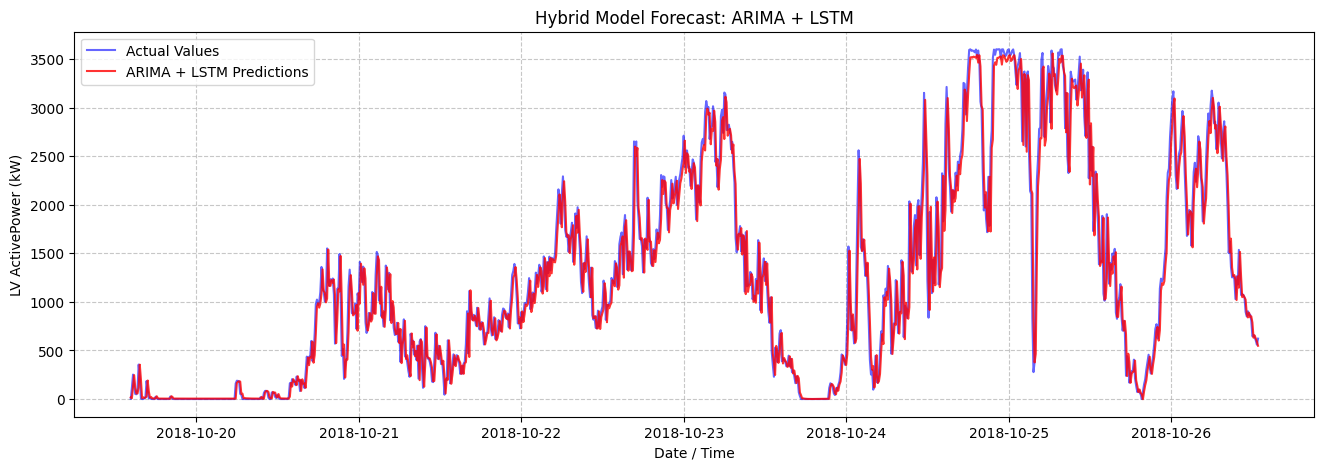

In [28]:
# Extract X-axis (Dates) aur Y-axis (Actual Values) for Plot 
plot_dates = time_series.index[-len(final_predictions):]
actual_values = time_series.values[-len(final_predictions):]

# 4. Plot the final combined predictions vs actual values
plt.figure(figsize=(16, 5))

plt.plot(plot_dates[:1000], actual_values[:1000], label='Actual Values', color='blue', alpha=0.6)
plt.plot(plot_dates[:1000], final_predictions[:1000], label='ARIMA + LSTM Predictions', color='red', alpha=0.8)

plt.title('Hybrid Model Forecast: ARIMA + LSTM')
plt.xlabel('Date / Time')
plt.ylabel('LV ActivePower (kW)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [24]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(actual_values, final_predictions))
mae = mean_absolute_error(actual_values, final_predictions)

print(f"Hybrid Model RMSE: {rmse:.2f}")
print(f"Hybrid Model MAE: {mae:.2f}")

Hybrid Model RMSE: 253.14
Hybrid Model MAE: 136.36


<div style="text-align: center; font-size: 16px;">
<b>Created by</b><br>
Priyanka Deore & Kunal Mahadule
</div>